# House Price Prediction -- Exploratory Analysis

This notebook is the exploration counterpart to `train.py`. It walks through loading the data, inspecting it, visualizing relationships, and building the same preprocessing + Linear Regression pipeline used in the final script.

Run all cells top to bottom (`Kernel > Restart & Run All`) to reproduce the plots and metrics.

## 1. Load and inspect the dataset

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np

df = pd.read_csv("../data/house_prices.csv")
print("Shape:", df.shape)
df.head()

Shape: (1206, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus,location
0,27294000.0,3481.0,5,3.0,3,0,yes,yes,yes,no,no,yes,semi-furnished,Chennai
1,31713000.0,2152.0,4,2.0,3,1,yes,no,no,yes,no,no,semi-furnished,Mumbai
2,24784000.0,1763.0,2,1.0,2,0,yes,no,no,no,no,yes,unfurnished,Delhi
3,22184000.0,4230.0,5,3.0,2,2,no,no,no,no,yes,no,furnished,Ahmedabad
4,42854000.0,2229.0,4,NaN,2,1,yes,yes,yes,yes,no,no,semi-furnished,Mumbai


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1206 entries, 0 to 1205
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             1206 non-null   float64
 1   area              1175 non-null   float64
 2   bedrooms          1206 non-null   int64  
 3   bathrooms         1185 non-null   float64
 4   stories           1206 non-null   int64  
 5   parking           1206 non-null   int64  
 6   mainroad          1206 non-null   str    
 7   guestroom         1206 non-null   str    
 8   basement          1206 non-null   str    
 9   hotwaterheating   1206 non-null   str    
 10  airconditioning   1206 non-null   str    
 11  prefarea          1206 non-null   str    
 12  furnishingstatus  1188 non-null   str    
 13  location          1206 non-null   str    
dtypes: float64(3), int64(3), str(8)
memory usage: 170.7 KB


In [3]:
df.describe(include="all")

,price,area,bedrooms,bathrooms,stories,parking,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus,location
count,1.206000e+03,1175.000000,1206.000000,1185.000000,1206.000000,1206.000000,1206,1206,1206,1206,1206,1206,1188,1206
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,2,3,8
top,NaN,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,no,semi-furnished,Mumbai
freq,NaN,NaN,NaN,NaN,NaN,NaN,1030,843,767,1025,747,899,458,208
mean,2.757606e+07,2759.396596,3.616915,2.559494,1.879768,1.014096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.374378e+07,975.820734,1.283478,1.021747,0.764115,0.825305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,3.810000e+06,620.000000,1.000000,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.823700e+07,2065.000000,3.000000,2.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2.416050e+07,2646.000000,4.000000,3.000000,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,3.358050e+07,3298.000000,4.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 price                0
area                31
bedrooms             0
bathrooms           21
stories              0
parking              0
mainroad             0
guestroom            0
basement             0
hotwaterheating      0
airconditioning      0
prefarea             0
furnishingstatus    18
location             0
dtype: int64

Duplicate rows: 5


## 2. Define the target and features

The target is `price`. Everything else is a candidate predictor.

In [5]:
TARGET = "price"
X = df.drop(columns=[TARGET])
y = df[TARGET]

## 3. Exploratory Data Analysis

### 3.1 Target distribution

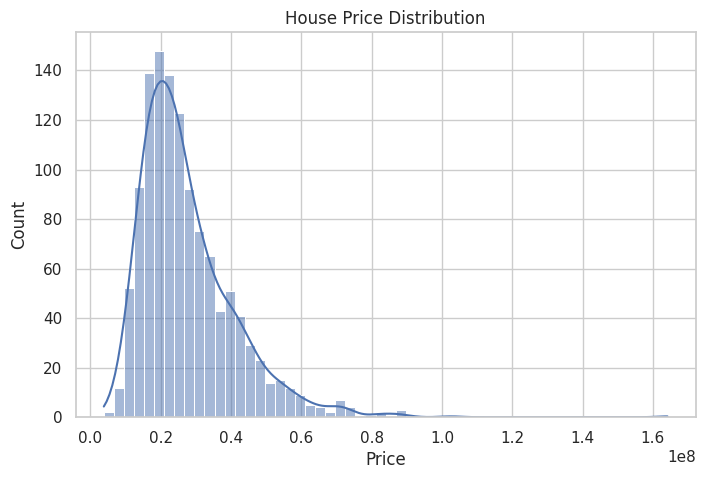

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.histplot(df[TARGET], kde=True)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

### 3.2 Numerical feature relationships

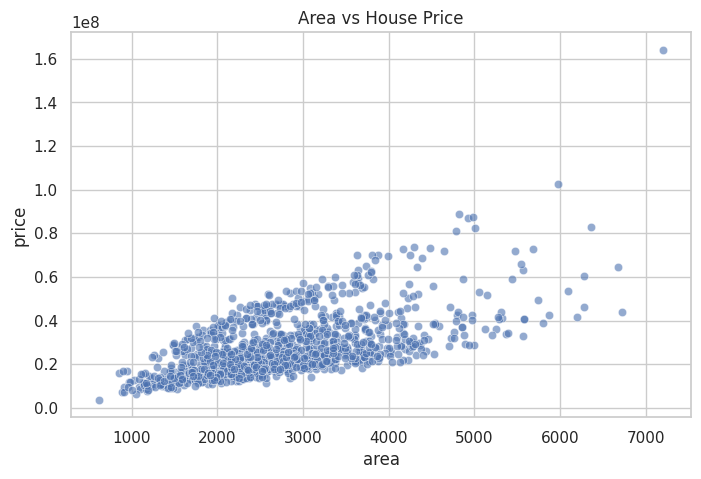

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="area", y=TARGET, alpha=0.6)
plt.title("Area vs House Price")
plt.show()

### 3.3 Correlation heatmap

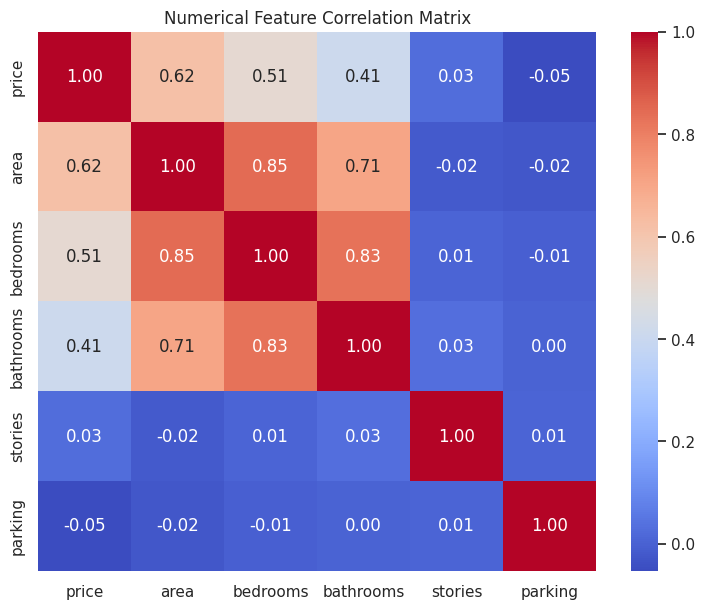

In [8]:
numeric_df = df.select_dtypes(include="number")
plt.figure(figsize=(9, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Numerical Feature Correlation Matrix")
plt.show()

### 3.4 Categorical exploration

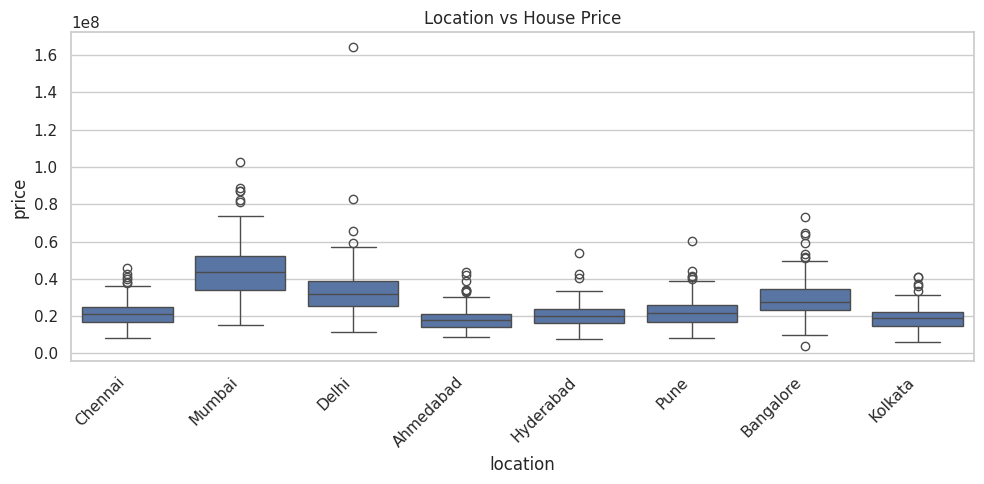

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="location", y=TARGET)
plt.xticks(rotation=45, ha="right")
plt.title("Location vs House Price")
plt.tight_layout()
plt.show()

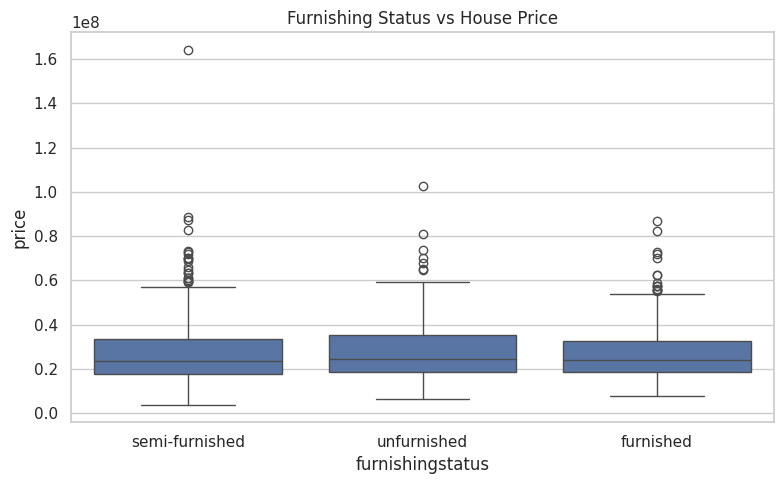

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="furnishingstatus", y=TARGET)
plt.title("Furnishing Status vs House Price")
plt.tight_layout()
plt.show()

## 4. Data cleaning

Drop exact duplicate rows. Missing values are handled later, inside the pipeline, so imputation statistics come from the training split only.

In [11]:
df = df.drop_duplicates().copy()
X = df.drop(columns=[TARGET])
y = df[TARGET]
print("Rows after de-duplication:", len(df))

Rows after de-duplication: 1201


## 5. Identify numerical and categorical features

`select_dtypes(include="number")` catches every numeric dtype. Everything else is treated as categorical -- this is safer than checking for `"object"` specifically, since recent pandas versions give plain string columns their own `"str"` dtype instead of `"object"`.

In [12]:
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus', 'location']


## 6. Train/test split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

Training rows: 960
Testing rows : 241


## 7. Preprocessing pipeline

Numeric columns are median-imputed. Categorical columns are imputed with the most frequent value, then one-hot encoded. Wrapping both in a `Pipeline`/`ColumnTransformer` means imputation and encoding statistics are learned from the training split only, which avoids data leakage.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

## 8. Train the Linear Regression model

In [15]:
from sklearn.linear_model import LinearRegression

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


## 9. Predictions and evaluation

In [16]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred,
})
comparison.head(10)

,Actual Price,Predicted Price
0,22077000.0,1.623678e+07
1,18458000.0,1.720619e+07
2,41551000.0,4.212801e+07
3,12102000.0,5.437277e+06
4,15592000.0,1.480191e+07
5,12154000.0,3.871453e+06
6,22448000.0,2.398259e+07
7,70001000.0,5.989904e+07
8,33810000.0,2.785316e+07
9,32149000.0,3.534382e+07


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:,.2f}")
print(f"MSE : {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2  : {r2:.4f}")

MAE : 3,608,940.80
MSE : 21,250,953,478,188.25
RMSE: 4,609,875.65
R2  : 0.8607


## 10. Actual vs predicted

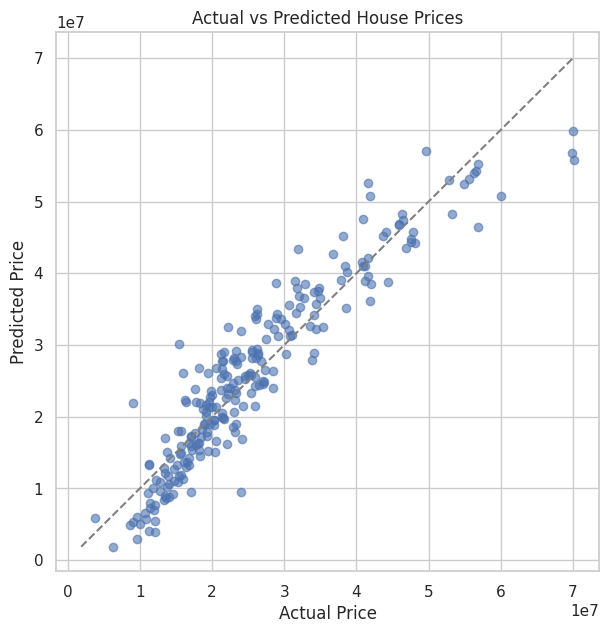

In [18]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6)
lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([lo, hi], [lo, hi], linestyle="--", color="gray")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

## 11. Residual analysis

Look for patterns rather than just the average error -- a curve or funnel shape would suggest non-linearity or changing variance that a straight-line model cannot capture.

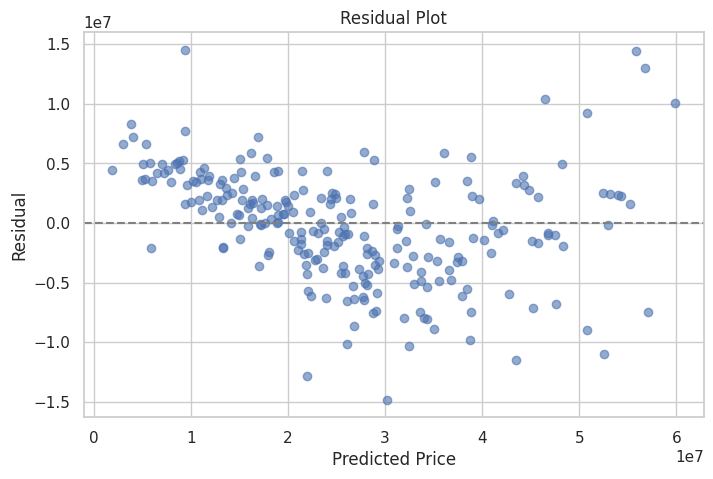

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--", color="gray")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

## 12. Save the trained pipeline

`train.py` performs this same save step (plus writing `metrics.json`) so `app.py` always has an up-to-date model to load. Re-running it here is optional and will overwrite that file with this session's fit.

In [20]:
import joblib
from pathlib import Path

model_path = Path("../models/house_price_model.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, model_path)
print("Saved to", model_path)

Saved to ../models/house_price_model.pkl


## Next steps

- Compare against Ridge and Random Forest, and run cross-validation (`compare_models.py` in the project root).
- Try feature engineering such as price-per-square-foot.
- Investigate the largest residuals to see whether they share a pattern.
- Swap in a real Kaggle housing dataset in `data/house_prices.csv` -- everything above adapts to the new columns automatically except the `TARGET` name, if the price column is called something else.